In [37]:
import os
import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt

In [26]:
stage = "river"

### Reading and compacting dfs

In [27]:
compact = False

In [28]:
# Iterate over files in dfs/*.parquet and combine to one df
dfs = []

read = []
for file in os.listdir('dfs'):
    if file.endswith('.parquet'):
        read.append(file)
        df = pd.read_parquet(f"dfs/{file}")
        dfs.append(df)

raw_df = pd.concat(dfs, ignore_index=True)

if compact:
    # Move read files to trash and write combined df to dfs/combined_{timestamp}.parquet
    trash = 'dfs/trash'
    for f in read:
        os.rename(f'dfs/{f}', f'{trash}/{f}')

    timestamp = datetime.now().strftime("%Y%m%d%H%M%S")
    raw_df.to_parquet(f'dfs/compacted_{timestamp}.parquet')

raw_df

,prob_P_has_hand_0,prob_P_has_hand_1,prob_P_has_hand_2,prob_P_has_hand_3,prob_P_has_hand_4,prob_P_has_hand_5,prob_P_has_hand_6,prob_P_has_hand_7,prob_P_has_hand_8,prob_P_has_hand_9,...,player_bet_in_stage,player_bet_in_game,opponent_bet_in_stage,opponent_bet_in_game,player_turn,player_has_bet,opponent_has_bet,pot,game_size,stage
0,0.000757,0.000887,0.001305,0.001482,0.001045,0.000277,0.000639,0.000418,0.000579,0.000847,...,253,710,510,967,True,True,True,1677,2679,river
1,0.000595,0.000678,0.000216,0.001389,0.000108,0.001179,0.000084,0.000408,0.001093,0.000935,...,0,207,46,253,True,False,True,460,1513,river
2,0.000404,0.001097,0.000654,0.000770,0.001412,0.000393,0.000757,0.000922,0.000968,0.001533,...,82,448,143,509,True,True,True,957,1823,river
3,0.001033,0.000740,0.000572,0.000162,0.000197,0.001461,0.000818,0.001001,0.001019,0.001444,...,478,782,864,1168,True,True,True,1950,3159,river
4,0.001026,0.000593,0.000650,0.000887,0.000901,0.000586,0.001030,0.000659,0.000218,0.000135,...,205,462,296,553,True,True,True,1015,1879,river


In [29]:
df = raw_df[raw_df["stage"] == stage]
df = df.drop(columns=["stage"])
df

,prob_P_has_hand_0,prob_P_has_hand_1,prob_P_has_hand_2,prob_P_has_hand_3,prob_P_has_hand_4,prob_P_has_hand_5,prob_P_has_hand_6,prob_P_has_hand_7,prob_P_has_hand_8,prob_P_has_hand_9,...,public_card_51,player_bet_in_stage,player_bet_in_game,opponent_bet_in_stage,opponent_bet_in_game,player_turn,player_has_bet,opponent_has_bet,pot,game_size
0,0.000757,0.000887,0.001305,0.001482,0.001045,0.000277,0.000639,0.000418,0.000579,0.000847,...,0.0,253,710,510,967,True,True,True,1677,2679
1,0.000595,0.000678,0.000216,0.001389,0.000108,0.001179,0.000084,0.000408,0.001093,0.000935,...,0.0,0,207,46,253,True,False,True,460,1513
2,0.000404,0.001097,0.000654,0.000770,0.001412,0.000393,0.000757,0.000922,0.000968,0.001533,...,0.0,82,448,143,509,True,True,True,957,1823
3,0.001033,0.000740,0.000572,0.000162,0.000197,0.001461,0.000818,0.001001,0.001019,0.001444,...,0.0,478,782,864,1168,True,True,True,1950,3159
4,0.001026,0.000593,0.000650,0.000887,0.000901,0.000586,0.001030,0.000659,0.000218,0.000135,...,0.0,205,462,296,553,True,True,True,1015,1879


### Preprocessing

In [30]:
# Divide all bets by game_size
def scale_bets(df):
    bet_columns = [
        "player_bet_in_stage",
        "player_bet_in_game",
        "opponent_bet_in_stage",
        "opponent_bet_in_game",
        "pot",
    ]
    df[bet_columns] = df[bet_columns].div(df["game_size"], axis=0)
    return df


scale_bets(df)
df

,prob_P_has_hand_0,prob_P_has_hand_1,prob_P_has_hand_2,prob_P_has_hand_3,prob_P_has_hand_4,prob_P_has_hand_5,prob_P_has_hand_6,prob_P_has_hand_7,prob_P_has_hand_8,prob_P_has_hand_9,...,public_card_51,player_bet_in_stage,player_bet_in_game,opponent_bet_in_stage,opponent_bet_in_game,player_turn,player_has_bet,opponent_has_bet,pot,game_size
0,0.000757,0.000887,0.001305,0.001482,0.001045,0.000277,0.000639,0.000418,0.000579,0.000847,...,0.0,0.094438,0.265024,0.190370,0.360956,True,True,True,0.625980,2679
1,0.000595,0.000678,0.000216,0.001389,0.000108,0.001179,0.000084,0.000408,0.001093,0.000935,...,0.0,0.000000,0.136814,0.030403,0.167217,True,False,True,0.304032,1513
2,0.000404,0.001097,0.000654,0.000770,0.001412,0.000393,0.000757,0.000922,0.000968,0.001533,...,0.0,0.044981,0.245749,0.078442,0.279210,True,True,True,0.524959,1823
3,0.001033,0.000740,0.000572,0.000162,0.000197,0.001461,0.000818,0.001001,0.001019,0.001444,...,0.0,0.151314,0.247547,0.273504,0.369737,True,True,True,0.617284,3159
4,0.001026,0.000593,0.000650,0.000887,0.000901,0.000586,0.001030,0.000659,0.000218,0.000135,...,0.0,0.109101,0.245875,0.157531,0.294305,True,True,True,0.540181,1879


In [31]:
# Scale range features so that min is 0 and mean is 0.5
def scale_ranges(df, training_min, training_mean):
    range_columns = [col for col in df.columns if col.startswith("prob_")]
    df[range_columns] = (df[range_columns] - training_min) / (training_mean - training_min) * 0.5
    return df

def get_training_min_and_mean(df):
    range_columns = [col for col in df.columns if col.startswith("prob_")]
    training_min = df[range_columns].to_numpy().min()
    training_mean = df[range_columns].to_numpy().mean()
    return training_min, training_mean

scale_ranges(df, *get_training_min_and_mean(df))
df

,prob_P_has_hand_0,prob_P_has_hand_1,prob_P_has_hand_2,prob_P_has_hand_3,prob_P_has_hand_4,prob_P_has_hand_5,prob_P_has_hand_6,prob_P_has_hand_7,prob_P_has_hand_8,prob_P_has_hand_9,...,public_card_51,player_bet_in_stage,player_bet_in_game,opponent_bet_in_stage,opponent_bet_in_game,player_turn,player_has_bet,opponent_has_bet,pot,game_size
0,0.502207,0.588367,0.865494,0.982394,0.692586,0.183639,0.423944,0.276969,0.383838,0.561456,...,0.0,0.094438,0.265024,0.190370,0.360956,True,True,True,0.625980,2679
1,0.394225,0.449744,0.143184,0.920764,0.071728,0.781828,0.055874,0.270460,0.724499,0.619917,...,0.0,0.000000,0.136814,0.030403,0.167217,True,False,True,0.304032,1513
2,0.267507,0.727486,0.433563,0.510295,0.936373,0.260677,0.501792,0.611221,0.641730,1.016223,...,0.0,0.044981,0.245749,0.078442,0.279210,True,True,True,0.524959,1823
3,0.684894,0.490583,0.378941,0.107611,0.130765,0.968606,0.542043,0.663662,0.675845,0.957478,...,0.0,0.151314,0.247547,0.273504,0.369737,True,True,True,0.617284,3159
4,0.680498,0.393336,0.430728,0.588247,0.597099,0.388253,0.683120,0.436721,0.144463,0.089191,...,0.0,0.109101,0.245875,0.157531,0.294305,True,True,True,0.540181,1879


In [32]:
# Make boolean features 0 or 1
def encode_bools(df):
    bool_columns = [
        "player_turn",
        "player_has_bet",
        "opponent_has_bet",
    ]
    df[bool_columns] = df[bool_columns].astype(int)
    return df

df = encode_bools(df)
df

,prob_P_has_hand_0,prob_P_has_hand_1,prob_P_has_hand_2,prob_P_has_hand_3,prob_P_has_hand_4,prob_P_has_hand_5,prob_P_has_hand_6,prob_P_has_hand_7,prob_P_has_hand_8,prob_P_has_hand_9,...,public_card_51,player_bet_in_stage,player_bet_in_game,opponent_bet_in_stage,opponent_bet_in_game,player_turn,player_has_bet,opponent_has_bet,pot,game_size
0,0.502207,0.588367,0.865494,0.982394,0.692586,0.183639,0.423944,0.276969,0.383838,0.561456,...,0.0,0.094438,0.265024,0.190370,0.360956,1,1,1,0.625980,2679
1,0.394225,0.449744,0.143184,0.920764,0.071728,0.781828,0.055874,0.270460,0.724499,0.619917,...,0.0,0.000000,0.136814,0.030403,0.167217,1,0,1,0.304032,1513
2,0.267507,0.727486,0.433563,0.510295,0.936373,0.260677,0.501792,0.611221,0.641730,1.016223,...,0.0,0.044981,0.245749,0.078442,0.279210,1,1,1,0.524959,1823
3,0.684894,0.490583,0.378941,0.107611,0.130765,0.968606,0.542043,0.663662,0.675845,0.957478,...,0.0,0.151314,0.247547,0.273504,0.369737,1,1,1,0.617284,3159
4,0.680498,0.393336,0.430728,0.588247,0.597099,0.388253,0.683120,0.436721,0.144463,0.089191,...,0.0,0.109101,0.245875,0.157531,0.294305,1,1,1,0.540181,1879


In [33]:
# Drop game_size column
df = df.drop(columns=["game_size"])
df

,prob_P_has_hand_0,prob_P_has_hand_1,prob_P_has_hand_2,prob_P_has_hand_3,prob_P_has_hand_4,prob_P_has_hand_5,prob_P_has_hand_6,prob_P_has_hand_7,prob_P_has_hand_8,prob_P_has_hand_9,...,public_card_50,public_card_51,player_bet_in_stage,player_bet_in_game,opponent_bet_in_stage,opponent_bet_in_game,player_turn,player_has_bet,opponent_has_bet,pot
0,0.502207,0.588367,0.865494,0.982394,0.692586,0.183639,0.423944,0.276969,0.383838,0.561456,...,0.0,0.0,0.094438,0.265024,0.190370,0.360956,1,1,1,0.625980
1,0.394225,0.449744,0.143184,0.920764,0.071728,0.781828,0.055874,0.270460,0.724499,0.619917,...,0.0,0.0,0.000000,0.136814,0.030403,0.167217,1,0,1,0.304032
2,0.267507,0.727486,0.433563,0.510295,0.936373,0.260677,0.501792,0.611221,0.641730,1.016223,...,0.0,0.0,0.044981,0.245749,0.078442,0.279210,1,1,1,0.524959
3,0.684894,0.490583,0.378941,0.107611,0.130765,0.968606,0.542043,0.663662,0.675845,0.957478,...,0.0,0.0,0.151314,0.247547,0.273504,0.369737,1,1,1,0.617284
4,0.680498,0.393336,0.430728,0.588247,0.597099,0.388253,0.683120,0.436721,0.144463,0.089191,...,0.0,0.0,0.109101,0.245875,0.157531,0.294305,1,1,1,0.540181


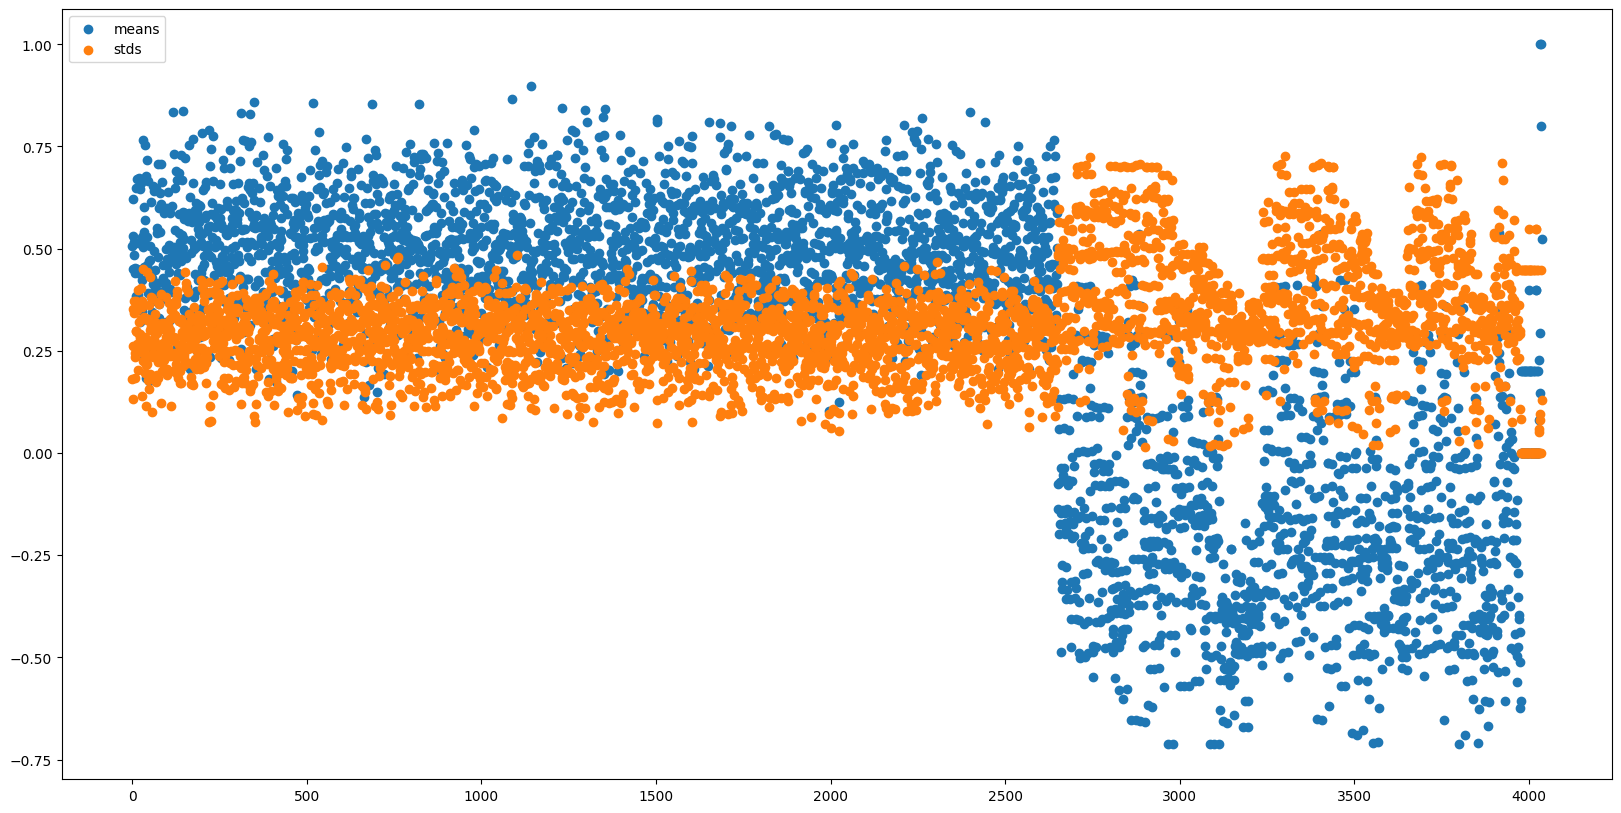

In [43]:
# Check that values are in correct range
fig, ax = plt.subplots(figsize=(20, 10))
plt.scatter(range(df.mean().size), df.mean(), label="means")
plt.scatter(range(df.std().size), df.std(), label="stds")
plt.legend()
plt.show()

In [34]:
Y_columns = [col for col in df.columns if col.startswith('value_of_hand_')]
X_columns = [col for col in df.columns if col not in Y_columns]
X = df[X_columns].values
Y = df[Y_columns].values
print(X.shape, Y.shape)

(5, 2712) (5, 1326)
